# MambaSegNet — Seismic Facies Segmentation (PyTorch Lightning)

**Dataset layout expected**
```
dataset/
  data/        train/  il_0.tif  xl_0.tif  ...   val/  xl_0.tif  ...   test/  xl_0.tif  ...
  annotations/ train/  il_0.png  xl_0.png  ...   val/  xl_0.png  ...   test/  xl_0.png  ...
```
Labels are integer PNG masks (one pixel value per class, 0-indexed).

## 0 — Configuration

In [1]:
import os, numpy as np
from pathlib import Path
import torch

# Reduces CUDA allocator fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.set_float32_matmul_precision("high")  # ← add this

# ── Paths ──────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("dataset")
TRAIN_DATA   = DATASET_ROOT / "data"        / "train"
TRAIN_LABELS = DATASET_ROOT / "annotations" / "train"
VAL_DATA     = DATASET_ROOT / "data"        / "val"
VAL_LABELS   = DATASET_ROOT / "annotations" / "val"
TEST_DATA    = DATASET_ROOT / "data"        / "test"
TEST_LABELS  = DATASET_ROOT / "annotations" / "test"
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Slice geometry ─────────────────────────────────────────────────────────
# Largest slice: 1006 x 590  →  round up to next multiple of 32
MAX_H, MAX_W = 1006, 590
CANVAS_H = int(np.ceil(MAX_H / 32) * 32)   # 1024
CANVAS_W = int(np.ceil(MAX_W / 32) * 32)   #  608

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_VARIANT = "small"   # tiny | small | base | large
NUM_CLASSES   = 6
IN_CHANNELS   = 1         # 1 = raw amplitude; 3 = enables pretrained VMamba
PRETRAINED    = False     # requires IN_CHANNELS=3
DATA_EXT      = "*.tif"

# ── Training ───────────────────────────────────────────────────────────────
EPOCHS           = 50
BATCH_SIZE       = 2
NUM_WORKERS      = 4
BASE_LR          = 1e-4
ENCODER_LR_SCALE = 0.1    # encoder lr = BASE_LR * ENCODER_LR_SCALE
WEIGHT_DECAY     = 1e-2
FREEZE_EPOCHS    = 5      # epochs with encoder frozen (pretrained mode only)
WARMUP_EPOCHS    = 5
SEED             = 42
PRECISION        = "16-mixed"   # '16-mixed' | 'bf16-mixed' | '32'

# ── Class names ────────────────────────────────────────────────────────────
CLASS_NAMES = [f"facies_{i}" for i in range(NUM_CLASSES)]
# e.g. CLASS_NAMES = ["background", "channel", "mass_transport", "slope", "delta", "carbonate"]

## 1 — Imports

In [2]:
import sys, random, warnings
import torch
import lightning as L
from lightning.pytorch.callbacks import (
    ModelCheckpoint, LearningRateMonitor, EarlyStopping
)
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore", category=UserWarning)
sys.path.insert(0, str(Path(".").resolve()))
from lightning_module import SeismicDataModule, MambaSegLightning

L.seed_everything(SEED, workers=True)

print(f"Lightning : {L.__version__}")
print(f"PyTorch   : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Seed set to 42


Lightning : 2.6.1
PyTorch   : 2.6.0+cu124
GPU       : NVIDIA GeForce RTX 4090
VRAM      : 25.4 GB


## 2 — Data Module

In [3]:
dm = SeismicDataModule(
    train_data=TRAIN_DATA, train_labels=TRAIN_LABELS,
    val_data=VAL_DATA,     val_labels=VAL_LABELS,
    test_data=TEST_DATA,   test_labels=TEST_LABELS,
    canvas_h=CANVAS_H,     canvas_w=CANVAS_W,
    in_channels=IN_CHANNELS,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    data_ext=DATA_EXT,
    num_classes=NUM_CLASSES,
)
dm.setup("fit")
dm.setup("test")

print(f"\nTrain : {len(dm.train_ds)} slices  ({len(dm.train_dataloader())} batches)")
print(f"Val   : {len(dm.val_ds)} slices")
print(f"Test  : {len(dm.test_ds)} slices")

[Dataset] 1121 samples (il=590, xl=531) | canvas 1024×608
[Dataset] 51 samples (il=0, xl=51) | canvas 1024×608
[DataModule] Computing class weights over training set...
[DataModule] Class weights: [0.947 0.288 2.873 0.381 8.957 1.059]
[Dataset] 200 samples (il=0, xl=200) | canvas 1024×608

Train : 1121 slices  (560 batches)
Val   : 51 slices
Test  : 200 slices


## 3 — Visualise Samples

/tmp/ipykernel_29/2507295945.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  PALETTE     = plt.cm.get_cmap("tab10", NUM_CLASSES)


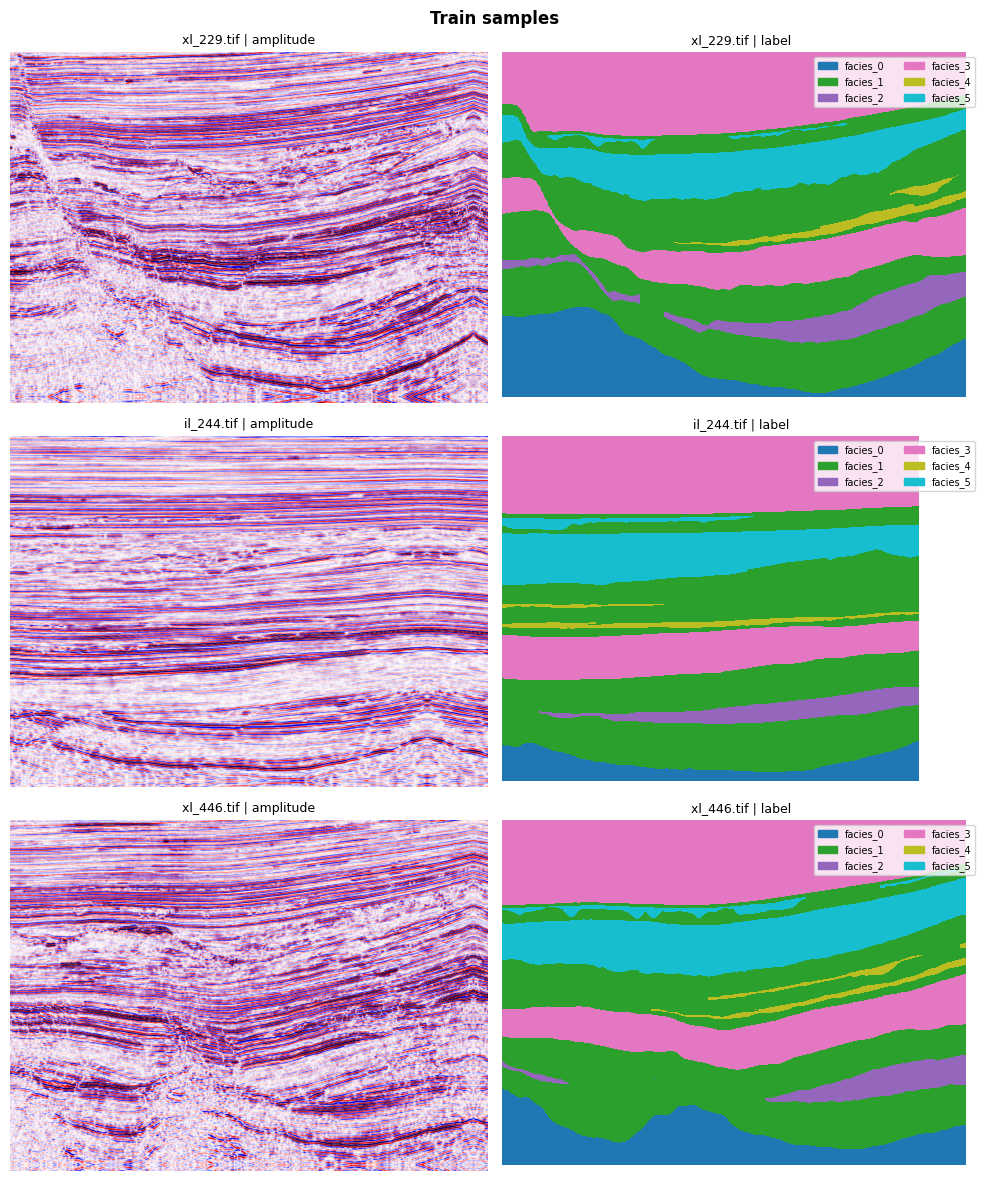

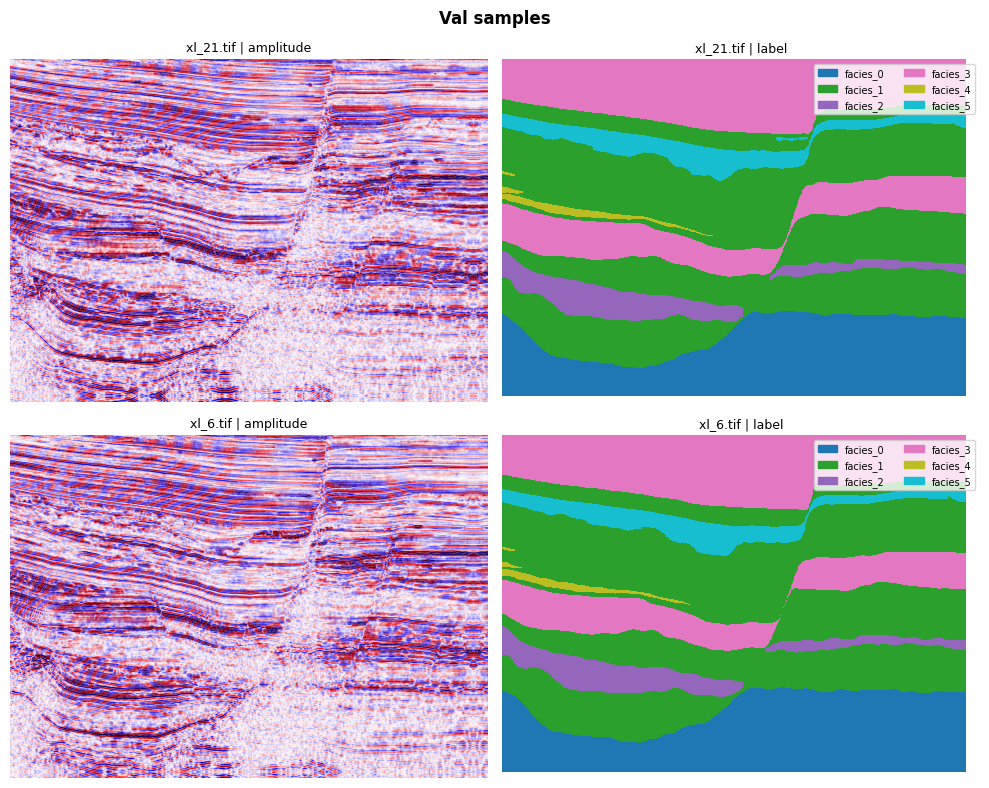

In [4]:
PALETTE     = plt.cm.get_cmap("tab10", NUM_CLASSES)
FACIES_CMAP = ListedColormap([PALETTE(i) for i in range(NUM_CLASSES)])

def show_samples(dataset, n=3, title=""):
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))
    if n == 1: axes = [axes]
    for ax_row, idx in zip(axes, idxs):
        amp_t, lbl_t, fname = dataset[idx]
        lbl_plot = lbl_t.numpy().astype(float)
        lbl_plot[lbl_plot < 0] = np.nan   # hide padded region
        ax_row[0].imshow(amp_t[0].numpy(), cmap="seismic", aspect="auto", vmin=-3, vmax=3)
        ax_row[0].set_title(f"{fname} | amplitude", fontsize=9); ax_row[0].axis("off")
        ax_row[1].imshow(lbl_plot, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                         aspect="auto", interpolation="nearest")
        ax_row[1].set_title(f"{fname} | label", fontsize=9); ax_row[1].axis("off")
        patches = [mpatches.Patch(color=PALETTE(i), label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
        ax_row[1].legend(handles=patches, loc="upper right", fontsize=7, ncol=2)
    fig.suptitle(title, fontweight="bold"); plt.tight_layout(); plt.show()

show_samples(dm.train_ds, n=3, title="Train samples")
show_samples(dm.val_ds,   n=2, title="Val samples")

## 4 — Class Distribution

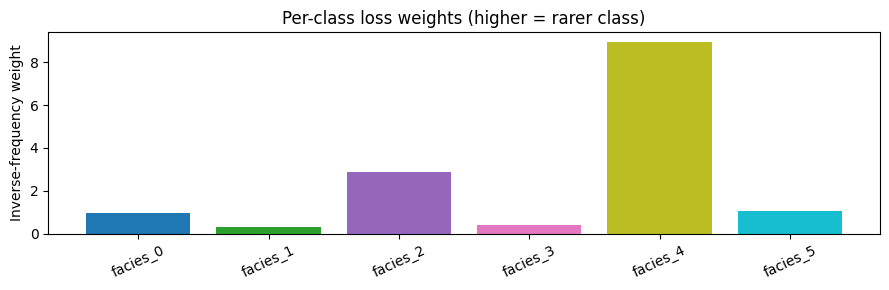

  facies_0                weight = 0.947
  facies_1                weight = 0.288
  facies_2                weight = 2.873
  facies_3                weight = 0.381
  facies_4                weight = 8.957
  facies_5                weight = 1.059


In [5]:
# Class weights were computed inside dm.setup() — visualise them here
w = dm.class_weights.numpy()
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(CLASS_NAMES, w, color=[PALETTE(i) for i in range(NUM_CLASSES)])
ax.set_ylabel("Inverse-frequency weight")
ax.set_title("Per-class loss weights (higher = rarer class)")
plt.xticks(rotation=25); plt.tight_layout(); plt.show()
for i, wi in enumerate(w):
    print(f"  {CLASS_NAMES[i]:22s}  weight = {wi:.3f}")

## 5 — Model

In [6]:
model = MambaSegLightning(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    variant=MODEL_VARIANT,
    pretrained=PRETRAINED,
    base_lr=BASE_LR,
    encoder_lr_scale=ENCODER_LR_SCALE,
    weight_decay=WEIGHT_DECAY,
    freeze_epochs=FREEZE_EPOCHS,
    max_epochs=EPOCHS,
    warmup_epochs=WARMUP_EPOCHS,
    class_weights=dm.class_weights,
    class_names=CLASS_NAMES,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"mamba_seg_{MODEL_VARIANT}  |  {n_params/1e6:.1f} M trainable params")

mamba_seg_small  |  15.5 M trainable params


## 6 — Trainer

In [7]:
from lightning.pytorch.callbacks import (
    ModelCheckpoint, LearningRateMonitor, EarlyStopping, RichProgressBar
)
callbacks = [
    # Save the best checkpoint by val mIoU
    ModelCheckpoint(
        dirpath=CHECKPOINT_DIR,
        filename="best-{epoch:02d}-{val/miou:.4f}",
        monitor="val/miou",
        mode="max",
        save_top_k=1,
        save_last=True,
        verbose=True,
    ),
    # Stop if val mIoU plateaus
    EarlyStopping(
        monitor="val/miou",
        mode="max",
        patience=10,
        verbose=True,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
]

logger = CSVLogger(save_dir=str(CHECKPOINT_DIR), name="logs")

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu",
    devices=1,
    precision=PRECISION,
    callbacks=callbacks,
    logger=logger,
    log_every_n_steps=10,
    gradient_clip_val=1.0,
    deterministic=False,
    enable_progress_bar=True,
    enable_model_summary=True
)
print("Trainer ready.")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainer ready.


## 7 — Train

In [8]:
trainer.fit(model, dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Dataset] 1121 samples (il=590, xl=531) | canvas 1024×608
[Dataset] 51 samples (il=0, xl=51) | canvas 1024×608


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net       │ MambaSegNet │ 15.5 M │ train │     0 │
│ 1 │ criterion │ DiceCELoss  │      0 │ train │     0 │
└───┴───────────┴─────────────┴────────┴───────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.5 M                                                                                               
Total estimated model params size (MB): 62                                                                         
Modules in train mode: 485                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

## 8 — Learning Curves

In [ ]:
import pandas as pd

csv_path = sorted((CHECKPOINT_DIR / "logs").rglob("metrics.csv"))[-1]
df = pd.read_csv(csv_path)

train_df = df.dropna(subset=["train/loss"]).reset_index(drop=True)
val_df   = df.dropna(subset=["val/loss"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_df["epoch"], train_df["train/loss"], label="train")
axes[0].plot(val_df["epoch"],   val_df["val/loss"],     label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("DiceCE Loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(train_df["epoch"], train_df["train/miou"], label="train")
axes[1].plot(val_df["epoch"],   val_df["val/miou"],     label="val")
if FREEZE_EPOCHS > 0:
    axes[1].axvline(FREEZE_EPOCHS, color="gray", linestyle="--",
                    label=f"encoder unfreezes (ep {FREEZE_EPOCHS})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mIoU")
axes[1].set_title("Mean IoU"); axes[1].legend()

plt.suptitle(f"mamba_seg_{MODEL_VARIANT}", fontweight="bold")
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "learning_curves.png", dpi=150)
plt.show()

## 9 — Test

In [ ]:
best_ckpt = trainer.checkpoint_callback.best_model_path
print(f"Best checkpoint: {best_ckpt}")
trainer.test(model, dm, ckpt_path=best_ckpt)

## 10 — Per-class IoU Bar Chart

In [ ]:
metrics   = trainer.logged_metrics
test_iou  = [float(metrics.get(f"test/iou_{n}", float("nan"))) for n in CLASS_NAMES]
test_miou = float(metrics.get("test/miou", float("nan")))

fig, ax = plt.subplots(figsize=(10, 4))
clean = [v if not np.isnan(v) else 0.0 for v in test_iou]
bars  = ax.bar(CLASS_NAMES, clean, color=[PALETTE(i) for i in range(NUM_CLASSES)])
ax.axhline(test_miou, color="black", linestyle="--",
           linewidth=1.5, label=f"mIoU = {test_miou:.3f}")
for bar, val in zip(bars, clean):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.1); ax.set_ylabel("IoU")
ax.set_title(f"Test IoU per class — mamba_seg_{MODEL_VARIANT}")
ax.legend(); plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "test_iou.png", dpi=150)
plt.show()

## 11 — Visual Predictions

In [ ]:
@torch.no_grad()
def visualise_predictions(net, dataset, device, n=4, save_path=None):
    net.eval().to(device)
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4.5*n))
    if n == 1: axes = [axes]
    for row, idx in enumerate(idxs):
        amp_t, lbl_t, fname = dataset[idx]
        logits = net(amp_t.unsqueeze(0).to(device))
        pred   = logits.squeeze(0).argmax(0).cpu().numpy()
        gt     = lbl_t.numpy()
        gt_plot = gt.astype(float); gt_plot[gt_plot < 0] = np.nan

        ax = axes[row]
        ax[0].imshow(amp_t[0].numpy(), cmap="seismic", aspect="auto", vmin=-3, vmax=3)
        ax[1].imshow(gt_plot, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                     aspect="auto", interpolation="nearest")
        ax[2].imshow(pred, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                     aspect="auto", interpolation="nearest")
        err = ((pred != gt) & (gt >= 0)).astype(np.float32)
        ax[3].imshow(err, cmap="Reds", aspect="auto", vmin=0, vmax=1)
        for a, t in zip(ax, ["Amplitude", "Ground Truth", "Prediction", "Errors"]):
            a.axis("off"); a.set_title(t, fontsize=9)
        ax[0].set_ylabel(fname, fontsize=8)

    patches = [mpatches.Patch(color=PALETTE(i), label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES,
               fontsize=8, bbox_to_anchor=(0.5, -0.01))
    plt.suptitle(f"mamba_seg_{MODEL_VARIANT} — Test predictions",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
visualise_predictions(model.net, dm.test_ds, DEVICE, n=4,
                      save_path=CHECKPOINT_DIR / "predictions.png")

## 12 — Full-section Tiled Inference

In [ ]:
import tifffile
from PIL import Image as PILImage

@torch.no_grad()
def predict_full_section(net, tiff_path, device,
                         tile_h=None, tile_w=None, overlap=64,
                         in_channels=1, num_classes=6):
    """Tiled inference with Hanning-window blending to avoid tile boundary artefacts."""
    tile_h = tile_h or CANVAS_H
    tile_w = tile_w or CANVAS_W

    amp = tifffile.imread(str(tiff_path)).astype(np.float32)
    if amp.ndim == 3:
        amp = amp[0] if amp.shape[0] < amp.shape[-1] else amp[..., 0]
    H, W = amp.shape
    amp  = (amp - amp.mean()) / (amp.std() + 1e-8)

    sh, sw  = tile_h - overlap, tile_w - overlap
    amp_p   = np.pad(amp, ((0, (sh - H % sh) % sh), (0, (sw - W % sw) % sw)), mode="reflect")
    Hp, Wp  = amp_p.shape
    win2d   = np.outer(np.hanning(tile_h) + 1e-6, np.hanning(tile_w) + 1e-6).astype(np.float32)

    logit_sum  = np.zeros((num_classes, Hp, Wp), dtype=np.float32)
    weight_sum = np.zeros((Hp, Wp), dtype=np.float32)

    net.eval().to(device)
    for y in range(0, Hp - tile_h + 1, sh):
        for x in range(0, Wp - tile_w + 1, sw):
            t = torch.from_numpy(amp_p[y:y+tile_h, x:x+tile_w]).unsqueeze(0).unsqueeze(0).to(device)
            if in_channels == 3: t = t.repeat(1, 3, 1, 1)
            out = net(t).squeeze(0).cpu().numpy()
            logit_sum[:, y:y+tile_h, x:x+tile_w]  += out * win2d
            weight_sum[y:y+tile_h, x:x+tile_w]     += win2d

    return (logit_sum / (weight_sum[None] + 1e-8)).argmax(0)[:H, :W].astype(np.int32)


if len(dm.test_ds.samples) > 0:
    demo_tiff, demo_lbl_path = dm.test_ds.samples[0]
    pred_full = predict_full_section(
        model.net, demo_tiff, DEVICE,
        in_channels=IN_CHANNELS, num_classes=NUM_CLASSES
    )
    amp_full = tifffile.imread(str(demo_tiff)).astype(np.float32)
    if amp_full.ndim == 3: amp_full = amp_full[0]
    gt_full  = np.array(PILImage.open(demo_lbl_path), dtype=np.int32)
    if gt_full.ndim == 3: gt_full = gt_full[..., 0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(amp_full, cmap="seismic", aspect="auto",
                   vmin=np.percentile(amp_full, 2), vmax=np.percentile(amp_full, 98))
    axes[0].set_title(f"{demo_tiff.name} — Amplitude"); axes[0].axis("off")
    axes[1].imshow(gt_full, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                   aspect="auto", interpolation="nearest")
    axes[1].set_title("Ground Truth"); axes[1].axis("off")
    axes[2].imshow(pred_full, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                   aspect="auto", interpolation="nearest")
    axes[2].set_title("Prediction (tiled)"); axes[2].axis("off")
    patches = [mpatches.Patch(color=PALETTE(i), label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES,
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / "full_section.png", dpi=150, bbox_inches="tight")
    plt.show()